## Spotify Clustering

### 1. Load and inspect the Spotify dataset
We'll import the dataset, take a quick peek at the schema, and confirm that the quantitative audio features we plan to cluster on are available.

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

from data_loader import (
    AUDIO_FEATURE_COLS,
    load_spotify,
    select_features,
    diagnostic_scale,
    remove_outliers,
    scale_features,
)
from clustering import (
    evaluate_kmeans,
    fit_kmeans,
    build_cluster_profile,
    build_pca_basis,
)
from visualization import (
    plot_elbow_silhouette,
    plot_cluster_heatmap,
    plot_pca_scatter,
)

sns.set_theme(style="whitegrid")

spotify_path = "dataset/spotify_dataset_lyrics.csv"
df = load_spotify(spotify_path)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.dtypes.to_frame(name="dtype").head(20)

/var/folders/sg/4lgvyv552gxd10hdnmvjlmjr0000gn/T/ipykernel_7312/2959025927.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Rows: 114000, Columns: 21


,dtype
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object


### 2. Select quantitative audio features
We'll keep only the numeric metrics that describe a track's sonic profile (danceability, energy, valence, speechiness, etc.) and drop rows with missing values for a clean clustering input.

In [ ]:
filtered_df, feature_df = select_features(df, AUDIO_FEATURE_COLS)
feature_df.head()

Using 114000 tracks with complete audio features


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666
1,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610
2,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826
3,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933
4,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853


### 3. Standardize features for diagnostics
We'll standardize the numeric audio features to study their distributions on a common scale. These z-scores both highlight skew (see the summary stats) and set up the next step where we drop extreme outliers.

In [ ]:
diagnostic_df, _ = diagnostic_scale(feature_df, AUDIO_FEATURE_COLS)
diagnostic_df.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,114000.0,-8.875551e-16,1.000004,-3.266080,-0.638465,0.076062,0.738728,2.409799
energy,114000.0,2.333572e-16,1.000004,-2.549946,-0.673415,0.173409,0.845303,1.425755
loudness,114000.0,-1.455989e-16,1.000004,-8.206295,-0.348763,0.249529,0.647396,2.543281
speechiness,114000.0,-1.316374e-16,1.000004,-0.800630,-0.461092,-0.338139,-0.001439,8.326228
acousticness,114000.0,2.632748e-16,1.000004,-0.947037,-0.896214,-0.438799,0.851344,2.048260
instrumentalness,114000.0,1.994506e-18,1.000004,-0.504112,-0.504112,-0.503977,-0.345819,2.726348
liveness,114000.0,-2.149080e-16,1.000004,-1.121737,-0.606969,-0.428376,0.312260,4.131002
valence,114000.0,-5.584617e-17,1.000004,-1.828544,-0.825690,-0.038835,0.805878,2.009303
tempo,114000.0,-2.792308e-17,1.000004,-4.074574,-0.764862,-0.004364,0.597876,4.043762
duration_ms,114000.0,2.393407e-17,1.000004,-2.125210,-0.502931,-0.140946,0.312001,46.685877


### 4. Remove extreme outliers
We trim tracks whose z-score exceeds ±4 on any feature so that rare edge cases (e.g., 40-minute ambient pieces) do not skew centroid placement.

In [ ]:
from data_loader import remove_outliers

filtered_df, feature_df = remove_outliers(filtered_df, feature_df, AUDIO_FEATURE_COLS)

Flagged 2946 tracks (>±4 z-score on any feature)
Retained 111054 tracks after trimming outliers


### 5. Standardize features for modeling
After trimming outliers, we refit the scaler to obtain the z-scored feature matrix (`scaled_df`) that powers the downstream weighting and clustering steps.

In [ ]:
from data_loader import scale_features

scaled_df, scaler = scale_features(feature_df, AUDIO_FEATURE_COLS)
scaled_df.describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,111054.0,-1.668644e-16,1.000005,-3.044947,-0.649274,0.071714,0.739947,2.428114
energy,111054.0,4.094831e-17,1.000005,-2.629751,-0.682078,0.167778,0.846850,1.436462
loudness,111054.0,-1.141434e-16,1.000005,-4.576793,-0.410759,0.238329,0.680825,2.812893
speechiness,111054.0,-1.658407e-16,1.000005,-0.746767,-0.563416,-0.388828,0.072919,5.790502
acousticness,111054.0,1.064656e-16,1.000005,-0.933755,-0.884798,-0.447238,0.822604,2.113865
instrumentalness,111054.0,5.323280e-17,1.000005,-0.495185,-0.495185,-0.495052,-0.359829,2.798147
liveness,111054.0,5.694374e-17,1.000005,-1.101359,-0.610261,-0.424606,0.336915,4.266807
valence,111054.0,-2.456899e-17,1.000005,-1.854692,-0.827421,-0.036616,0.804583,2.002420
tempo,111054.0,5.789067e-16,1.000005,-3.138650,-0.771363,-0.010885,0.593501,3.390281
duration_ms,111054.0,-9.827594e-17,1.000005,-2.787595,-0.624989,-0.153164,0.437854,5.337947


### 6. Derive feature weights from PCA loadings
To highlight the axes that create the strongest separation, we fit a quick PCA on the standardized matrix and use the average absolute loading of PC1/PC2 as a heuristic weight for each feature. This amplifies attributes (e.g., energy, acousticness, speechiness) that drive the largest variance in the first two components.

Evaluating k:   0%|          | 0/9 [00:00<?, ?k/s]

,k,inertia,silhouette
0,2,895727.647582,0.227038


Evaluating k:  11%|█         | 1/9 [02:49<22:32, 169.08s/k]

,k,inertia,silhouette
1,3,800824.466515,0.152492


Evaluating k:  22%|██▏       | 2/9 [05:25<18:52, 161.80s/k]

...

Evaluating k:  78%|███████▊  | 7/9 [19:36<05:43, 171.87s/k]

,k,inertia,silhouette
7,9,533480.961201,0.145771


Evaluating k:  89%|████████▉ | 8/9 [22:36<02:54, 174.46s/k]

,k,inertia,silhouette
8,10,510393.04452,0.144542


Evaluating k: 100%|██████████| 9/9 [25:37<00:00, 170.80s/k]


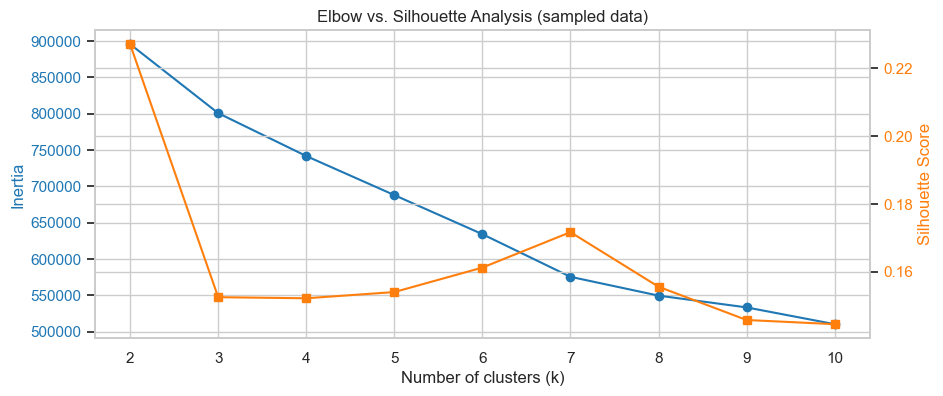

,k,inertia,silhouette
0,2,895727.647582,0.227038
1,3,800824.466515,0.152492
2,4,741778.185429,0.152172
3,5,688043.397548,0.154001
4,6,634266.882109,0.161214
5,7,575573.099999,0.171653
6,8,549695.410941,0.155575
7,9,533480.961201,0.145771
8,10,510393.044520,0.144542


In [ ]:
k_eval = evaluate_kmeans(scaled_df, k_values=range(2, 11))
plot_elbow_silhouette(k_eval)
k_eval

### 7. Fit K-means with a chosen \(k\)
Pick a \(k\) from the evaluation above (here we go with `k=5`, but feel free to adjust) and fit the final model. We'll attach the resulting cluster labels back to the numeric feature frame to perform downstream analysis.

In [ ]:
k_final = 5  # adjust based on evaluation above
kmeans_final, clusters = fit_kmeans(scaled_df, k=k_final)

clustered_df = filtered_df.copy()
clustered_df["cluster"] = clusters

clustered_df[["track_name", "artist", "genre", "emotion", "cluster"] + AUDIO_FEATURE_COLS].head()

,track_name,artists,track_genre,cluster,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,Comedy,Gen Hoshino,acoustic,1,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917,230666
1,Ghost - Acoustic,Ben Woodward,acoustic,0,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489,149610
2,To Begin Again,Ingrid Michaelson;ZAYN,acoustic,0,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332,210826
3,Can't Help Falling In Love,Kina Grannis,acoustic,0,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740,201933
4,Hold On,Chord Overstreet,acoustic,0,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949,198853


### 8. Profile clusters via feature averages
Aggregating the standardized audio features by cluster gives a quick sense of each group's sonic signature. We'll visualize the mean z-score per feature using a heatmap.

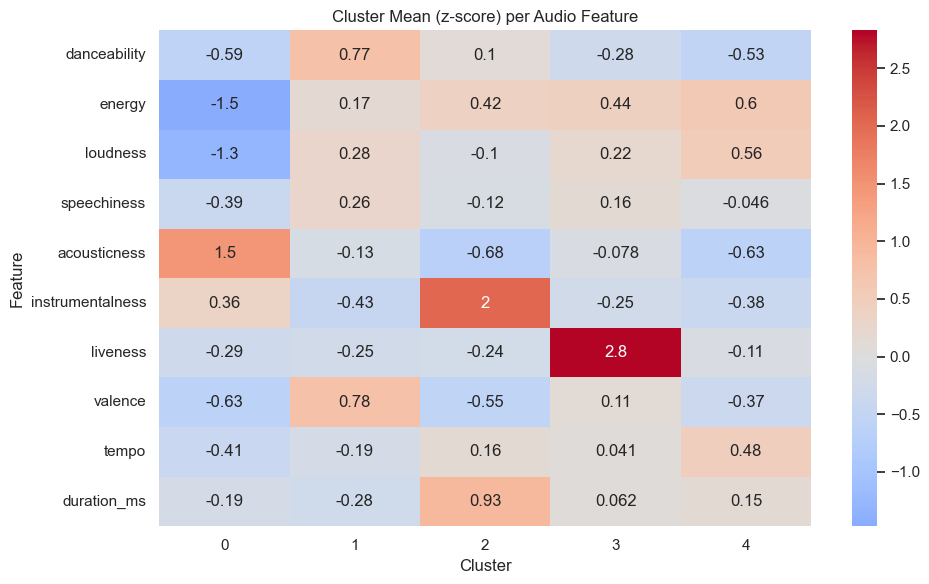

cluster,0,1,2,3,4
danceability,-0.588496,0.774216,0.100286,-0.279759,-0.534592
energy,-1.471140,0.165421,0.421846,0.436790,0.595451
loudness,-1.292169,0.283348,-0.100809,0.223928,0.557910
speechiness,-0.388434,0.258492,-0.123000,0.155766,-0.045770
acousticness,1.452356,-0.130709,-0.676631,-0.077660,-0.627218
instrumentalness,0.356529,-0.430587,2.040672,-0.247781,-0.383710
liveness,-0.287778,-0.254485,-0.238880,2.827603,-0.109374
valence,-0.629640,0.776353,-0.552004,0.113006,-0.371608
tempo,-0.408539,-0.189708,0.155703,0.040750,0.477177
duration_ms,-0.194287,-0.278562,0.929662,0.062100,0.147411


In [ ]:
cluster_profile = build_cluster_profile(scaled_df, clusters, cluster_col="cluster")
plot_cluster_heatmap(cluster_profile, title="Cluster Mean (z-score) per Audio Feature")
cluster_profile

### 9. Visualize clusters in 2D via PCA
Projecting the high-dimensional feature space down to two principal components lets us visualize how well-separated the learned clusters are (with the usual caveats about dimensionality reduction).

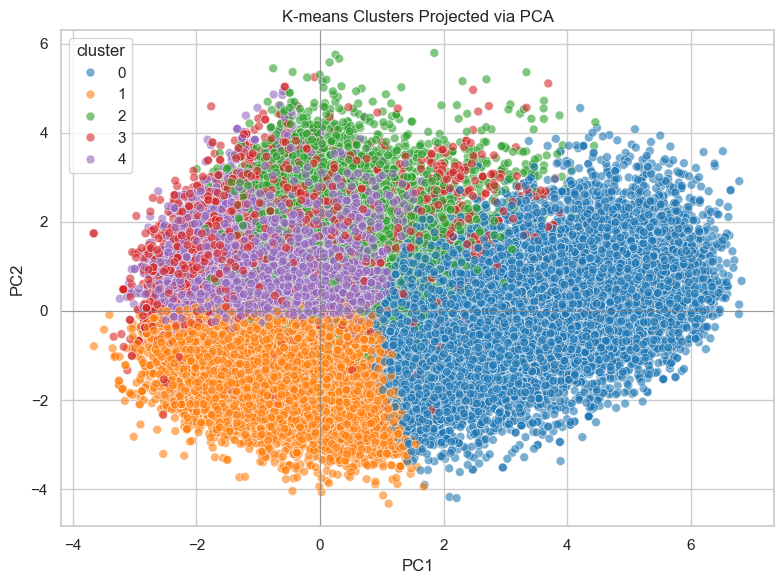

array([0.28304757, 0.16045612])

In [ ]:
plot_pca_scatter(scaled_df, clusters, cluster_col="cluster")